In [1]:
import subprocess, sys

# Auto-install mlflow if missing
try:
    import mlflow
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "mlflow", "-q"])
    import mlflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
import os
import mlflow.sklearn
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

print("All imports successful ✅")

All imports successful ✅


In [16]:
# Run this in a new cell to find where you are
import os
print("Notebook is running from:", os.getcwd())
print("\nFiles 2 levels up:")
print(os.listdir("../../"))

Notebook is running from: /Users/rajukotturi45gmail.com/Documents/ML PROJECTS/product-recommender/ml/notebooks

Files 2 levels up:
['infra', '.DS_Store', 'frontend', '.pytest_cache', 'tests', 'product-recommender-env', 'backend', 'README.md', '.gitignore', 'ml', '.env', 'requirement.txt', '.git', 'Data']


In [17]:
# 1M dataset uses :: separator, not comma
ratings = pd.read_csv(
    "../../Data/raw/ratings.dat",
    sep="::", engine="python",
    names=["userId", "movieId", "rating", "timestamp"]
)

movies = pd.read_csv(
    "../../Data/raw/movies.dat",
    sep="::", engine="python",
    names=["movieId", "title", "genres"],
    encoding="latin-1"
)

users = pd.read_csv(
    "../../Data/raw/users.dat",
    sep="::", engine="python",
    names=["userId", "gender", "age", "occupation", "zipcode"]
)

print(f"Ratings : {ratings.shape}")   # expect (1000209, 4)
print(f"Movies  : {movies.shape}")    # expect (3883, 3)
print(f"Users   : {users.shape}")     # expect (6040, 5)

Ratings : (1000209, 4)
Movies  : (3883, 3)
Users   : (6040, 5)


In [18]:
svd_model     = joblib.load("../../backend/saved_models/svd_model.pkl")
cosine_sim    = joblib.load("../../backend/saved_models/cosine_sim.pkl")
movie_indices = joblib.load("../../backend/saved_models/movie_indices.pkl")
tfidf_matrix  = joblib.load("../../backend/saved_models/tfidf_matrix.pkl")

print("SVD model loaded     ✅")
print("Cosine sim loaded    ✅")
print("Movie indices loaded ✅")
print("TF-IDF matrix loaded ✅")

SVD model loaded     ✅
Cosine sim loaded    ✅
Movie indices loaded ✅
TF-IDF matrix loaded ✅


In [19]:
# Surprise needs its own Dataset format
reader   = Reader(rating_scale=(0.5, 5.0))
data     = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"Train size : {trainset.n_ratings:,} ratings")
print(f"Test size  : {len(testset):,} ratings")
print("Surprise dataset ready ✅")

Train size : 800,167 ratings
Test size  : 200,042 ratings
Surprise dataset ready ✅


In [20]:
# These are industry-standard rec system metrics
# RMSE alone is not enough — you need ranking quality metrics

def precision_at_k(recommended, relevant, k=10):
    """Of top-k recs, how many did user actually like?"""
    hits = len(set(recommended[:k]) & set(relevant))
    return hits / k

def recall_at_k(recommended, relevant, k=10):
    """Of all movies user liked, how many did we catch in top-k?"""
    hits = len(set(recommended[:k]) & set(relevant))
    return hits / len(relevant) if relevant else 0

def ndcg_at_k(recommended, relevant, k=10):
    """Are best recommendations ranked highest?"""
    dcg  = sum([1 / np.log2(i + 2) for i, m in enumerate(recommended[:k]) if m in relevant])
    idcg = sum([1 / np.log2(i + 2) for i in range(min(len(relevant), k))])
    return dcg / idcg if idcg > 0 else 0


# Build relevant_items from testset
# A movie is "relevant" if user rated it >= 4.0
relevant_items = {}
for uid, iid, true_r in testset:
    if true_r >= 4.0:
        relevant_items.setdefault(uid, []).append(iid)

print(f"Users with relevant items: {len(relevant_items)}")
print("Evaluation functions ready ✅")

Users with relevant items: 5977
Evaluation functions ready ✅


In [21]:
def get_collaborative_scores(user_id, movies_df, ratings_df, svd_model):
    """SVD predicts what rating a user would give every unrated movie."""
    rated = ratings_df[ratings_df['userId'] == user_id]['movieId'].tolist()
    predictions = []
    for _, row in movies_df.iterrows():
        movie_id = row['movieId']
        if movie_id not in rated:
            pred = svd_model.predict(user_id, movie_id).est
            predictions.append({'movieId': movie_id, 'title': row['title'], 'collab_score': pred})
    return pd.DataFrame(predictions)


# Test with User 1
collab_scores = get_collaborative_scores(1, movies, ratings, svd_model)
print(f"Collaborative scores for {len(collab_scores)} movies")
print(collab_scores.head())

Collaborative scores for 3830 movies
   movieId                               title  collab_score
0        2                      Jumanji (1995)      3.354990
1        3             Grumpier Old Men (1995)      3.367143
2        4            Waiting to Exhale (1995)      2.958505
3        5  Father of the Bride Part II (1995)      3.348735
4        6                         Heat (1995)      4.292014


In [22]:
def get_content_scores(user_id, movies_df, ratings_df, cosine_sim, movie_indices):
    """Find movies similar to what user already liked using TF-IDF genre similarity."""
    liked = (ratings_df[
        (ratings_df['userId'] == user_id) & (ratings_df['rating'] >= 4.0)
    ].merge(movies_df, on='movieId')['title'].tolist())

    watched_ids    = ratings_df[ratings_df['userId'] == user_id]['movieId'].tolist()
    content_scores = {}

    for liked_title in liked:
        if liked_title not in movie_indices:
            continue
        idx        = movie_indices[liked_title]
        sim_scores = list(enumerate(cosine_sim[idx]))
        for movie_idx, score in sim_scores:
            movie_id = movies_df.iloc[movie_idx]['movieId']
            if movie_id not in watched_ids:
                content_scores[movie_id] = max(content_scores.get(movie_id, 0), score)

    return pd.DataFrame(content_scores.items(), columns=['movieId', 'content_score'])


# Test with User 1
content_scores = get_content_scores(1, movies, ratings, cosine_sim, movie_indices)
print(f"Content scores for {len(content_scores)} movies")
print(content_scores.head())

Content scores for 3830 movies
   movieId  content_score
0        2       0.196269
1        3       0.067616
2        4       0.161822
3        5       0.066389
4        6       0.154751


In [23]:
# SVD scores are 0.5–5.0 range
# Content scores are 0.0–1.0 range
# Must normalize both to 0–1 before combining

def normalize_scores(df, column):
    scaler     = MinMaxScaler()
    df         = df.copy()
    df[column] = scaler.fit_transform(df[[column]])
    return df

collab_norm  = normalize_scores(collab_scores,  'collab_score')
content_norm = normalize_scores(content_scores, 'content_score')

print("Collaborative scores normalized ✅")
print(collab_norm['collab_score'].describe().round(4))
print()
print("Content scores normalized ✅")
print(content_norm['content_score'].describe().round(4))

Collaborative scores normalized ✅
count    3830.0000
mean        0.5811
std         0.1641
min         0.0000
25%         0.4846
50%         0.6067
75%         0.6873
max         1.0000
Name: collab_score, dtype: float64

Content scores normalized ✅
count    3830.0000
mean        0.1908
std         0.1432
min         0.0000
25%         0.0894
50%         0.1602
75%         0.2520
max         1.0000
Name: content_score, dtype: float64


In [24]:
# 60% collaborative + 40% content
# Collaborative weighted higher because SVD has personalization signal
COLLAB_WEIGHT  = 0.6
CONTENT_WEIGHT = 0.4

hybrid = collab_norm.merge(content_norm, on='movieId', how='left')
hybrid['content_score'] = hybrid['content_score'].fillna(0)
hybrid['hybrid_score']  = (
    COLLAB_WEIGHT  * hybrid['collab_score'] +
    CONTENT_WEIGHT * hybrid['content_score']
)
hybrid = hybrid.sort_values('hybrid_score', ascending=False)

print(f"Hybrid scores computed ✅")
print(hybrid.head(10))

Hybrid scores computed ✅
      movieId                             title  collab_score  content_score  \
2250     2360  Celebration, The (Festen) (1998)      0.924512       0.677028   
3792     3915                  Girlfight (2000)      0.657381       1.000000   
3829     3952             Contender, The (2000)      0.784765       0.790222   
610       625                Asfour Stah (1990)      0.635386       1.000000   
3628     3750             Boricua's Bond (2000)      0.635386       1.000000   
2888     3006               Insider, The (1999)      0.833973       0.691822   
3388     3510                  Frequency (2000)      0.763830       0.790222   
3430     3552                 Caddyshack (1980)      0.788367       0.743493   
3780     3903                    Urbania (2000)      0.592921       1.000000   
1741     1842                    Illtown (1996)      0.680900       0.862930   

      hybrid_score  
2250      0.825519  
3792      0.794429  
3829      0.786948  
610       

In [25]:
def get_hybrid_recommendations(user_id, movies_df, ratings_df,
                                svd_model, cosine_sim, movie_indices,
                                collab_weight=0.6, content_weight=0.4, n=10):
    collab  = get_collaborative_scores(user_id, movies_df, ratings_df, svd_model)
    collab  = normalize_scores(collab, 'collab_score')
    content = get_content_scores(user_id, movies_df, ratings_df, cosine_sim, movie_indices)
    content = normalize_scores(content, 'content_score')

    hybrid  = collab.merge(content, on='movieId', how='left')
    hybrid['content_score'] = hybrid['content_score'].fillna(0)
    hybrid['hybrid_score']  = collab_weight * hybrid['collab_score'] + content_weight * hybrid['content_score']
    hybrid  = hybrid.sort_values('hybrid_score', ascending=False).head(n)
    hybrid  = hybrid.merge(movies_df[['movieId', 'genres']], on='movieId')

    return hybrid[['title', 'genres', 'collab_score', 'content_score', 'hybrid_score']].reset_index(drop=True)


print("Computing top 10 for User 1... ⏳")
hybrid_recs = get_hybrid_recommendations(
    user_id=1, movies_df=movies, ratings_df=ratings,
    svd_model=svd_model, cosine_sim=cosine_sim, movie_indices=movie_indices
)
print("\n🎬 Top 10 Hybrid Recommendations for User 1:")
print(hybrid_recs.to_string(index=False))

Computing top 10 for User 1... ⏳

🎬 Top 10 Hybrid Recommendations for User 1:
                           title         genres  collab_score  content_score  hybrid_score
Celebration, The (Festen) (1998)          Drama      0.924512       0.677028      0.825519
                Girlfight (2000)          Drama      0.657381       1.000000      0.794429
           Contender, The (2000) Drama|Thriller      0.784765       0.790222      0.786948
              Asfour Stah (1990)          Drama      0.635386       1.000000      0.781231
           Boricua's Bond (2000)          Drama      0.635386       1.000000      0.781231
             Insider, The (1999)          Drama      0.833973       0.691822      0.777112
                Frequency (2000) Drama|Thriller      0.763830       0.790222      0.774387
               Caddyshack (1980)         Comedy      0.788367       0.743493      0.770417
                  Urbania (2000)          Drama      0.592921       1.000000      0.755753
            

In [26]:
svd_only     = collab_norm.sort_values('collab_score', ascending=False).head(10)
content_only = content_norm.merge(movies[['movieId', 'title']], on='movieId') \
                            .sort_values('content_score', ascending=False).head(10)

print("="*50 + "\nSVD ONLY — Top 5\n" + "="*50)
print(svd_only[['title', 'collab_score']].head().to_string(index=False))

print("\n" + "="*50 + "\nCONTENT ONLY — Top 5\n" + "="*50)
print(content_only[['title', 'content_score']].head().to_string(index=False))

print("\n" + "="*50 + "\nHYBRID — Top 5\n" + "="*50)
print(hybrid_recs[['title', 'hybrid_score']].head().to_string(index=False))

SVD ONLY — Top 5
                                                              title  collab_score
                                                     Sanjuro (1962)      1.000000
Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954)      0.968073
                                   Shawshank Redemption, The (1994)      0.967778
                                                 Rear Window (1954)      0.964022
                                            Inherit the Wind (1960)      0.958793

CONTENT ONLY — Top 5
                 title  content_score
        Urbania (2000)            1.0
 Two Jakes, The (1990)            1.0
    Asfour Stah (1990)            1.0
 Boricua's Bond (2000)            1.0
Up at the Villa (2000)            1.0

HYBRID — Top 5
                           title  hybrid_score
Celebration, The (Festen) (1998)      0.825519
                Girlfight (2000)      0.794429
           Contender, The (2000)      0.786948
              Asfour Stah (1990)     

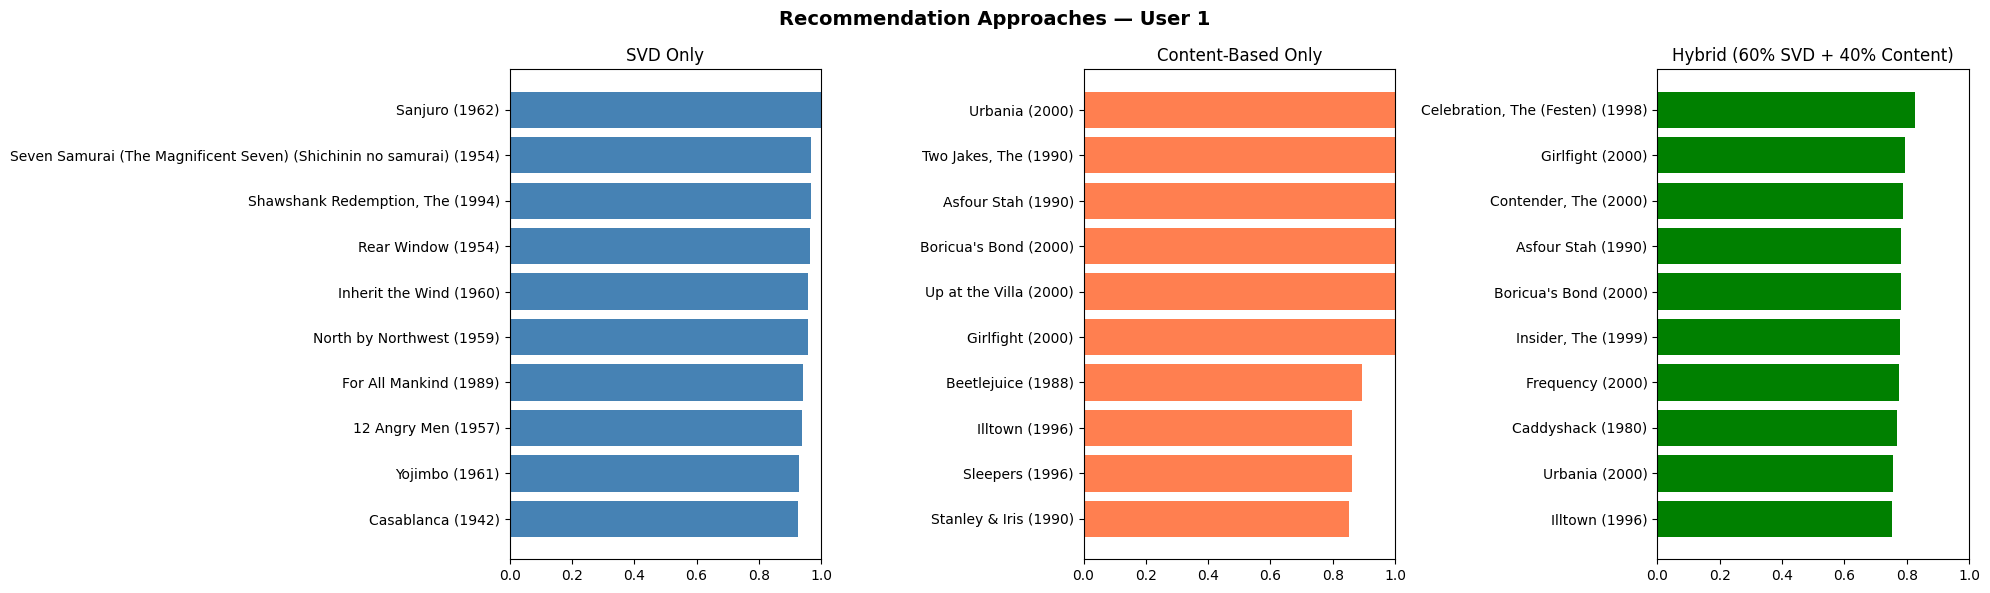

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].barh(svd_only['title'].head(10), svd_only['collab_score'].head(10), color='steelblue')
axes[0].set_title("SVD Only")
axes[0].set_xlim(0, 1)
axes[0].invert_yaxis()

axes[1].barh(content_only['title'].head(10), content_only['content_score'].head(10), color='coral')
axes[1].set_title("Content-Based Only")
axes[1].set_xlim(0, 1)
axes[1].invert_yaxis()

axes[2].barh(hybrid_recs['title'], hybrid_recs['hybrid_score'], color='green')
axes[2].set_title("Hybrid (60% SVD + 40% Content)")
axes[2].set_xlim(0, 1)
axes[2].invert_yaxis()

plt.suptitle("Recommendation Approaches — User 1", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# Shows how changing the collab/content balance changes results
weight_combos = [(1.0, 0.0), (0.7, 0.3), (0.6, 0.4), (0.3, 0.7), (0.0, 1.0)]

print(f"{'Collab':>8} {'Content':>8}  {'Top Recommendation'}")
print("-" * 65)

for cw, ctw in weight_combos:
    recs = get_hybrid_recommendations(
        user_id=1, movies_df=movies, ratings_df=ratings,
        svd_model=svd_model, cosine_sim=cosine_sim, movie_indices=movie_indices,
        collab_weight=cw, content_weight=ctw, n=1
    )
    print(f"{cw:>8.1f} {ctw:>8.1f}  {recs.iloc[0]['title']}")

  Collab  Content  Top Recommendation
-----------------------------------------------------------------
     1.0      0.0  Sanjuro (1962)
     0.7      0.3  Celebration, The (Festen) (1998)
     0.6      0.4  Celebration, The (Festen) (1998)
     0.3      0.7  Girlfight (2000)
     0.0      1.0  Urbania (2000)


In [30]:
# ── CELL 14 FIXED — compare by movieId throughout ─────────────
precision_scores, recall_scores, ndcg_scores = [], [], []

def precision_at_k_id(recommended_ids, relevant_ids, k=10):
    hits = len(set(recommended_ids[:k]) & set(relevant_ids))
    return hits / k

def recall_at_k_id(recommended_ids, relevant_ids, k=10):
    hits = len(set(recommended_ids[:k]) & set(relevant_ids))
    return hits / len(relevant_ids) if relevant_ids else 0

def ndcg_at_k_id(recommended_ids, relevant_ids, k=10):
    dcg  = sum([1 / np.log2(i + 2) for i, mid in enumerate(recommended_ids[:k]) if mid in relevant_ids])
    idcg = sum([1 / np.log2(i + 2) for i in range(min(len(relevant_ids), k))])
    return dcg / idcg if idcg > 0 else 0

    # title → movieId lookup
    title_to_id = dict(zip(movies['title'], movies['movieId']))

    # IMPORTANT: evaluate recommendations against held-out items.
    # Remove held-out (userId, movieId) pairs from the history used to generate recs.
    test_pairs = {(int(uid), int(iid)) for (uid, iid, true_r) in testset}
    train_ratings = ratings[
        ~ratings[['userId', 'movieId']].astype(int).apply(tuple, axis=1).isin(test_pairs)
    ]

    test_users = [u for u in relevant_items if len(relevant_items[u]) >= 3][:100]
    print(f"Evaluating on {len(test_users)} users... ⏳")

    for i, uid in enumerate(test_users):
        if i % 10 == 0:
            print(f"  Progress: {i}/{len(test_users)}")

        recs = get_hybrid_recommendations(
            user_id=uid, movies_df=movies, ratings_df=train_ratings,
            svd_model=svd_model, cosine_sim=cosine_sim,
            movie_indices=movie_indices, n=10
        )

    # Convert recommended titles → movieIds
    recommended_ids = [title_to_id[t] for t in recs['title'].tolist() if t in title_to_id]

    # relevant_ids already are movieIds from testset
    relevant_ids = relevant_items[uid]

    if not relevant_ids:
        continue

    precision_scores.append(precision_at_k_id(recommended_ids, relevant_ids))
    recall_scores.append(recall_at_k_id(recommended_ids, relevant_ids))
    ndcg_scores.append(ndcg_at_k_id(recommended_ids, relevant_ids))

p10 = round(float(np.mean(precision_scores)), 4)
r10 = round(float(np.mean(recall_scores)),    4)
n10 = round(float(np.mean(ndcg_scores)),      4)

print("\n" + "="*40)
print("📊 EVALUATION RESULTS")
print("="*40)
print(f"Precision@10 : {p10}")
print(f"Recall@10    : {r10}")
print(f"NDCG@10      : {n10}")
print("="*40)

Evaluating on 100 users... ⏳
  Progress: 0/100
  Progress: 10/100
  Progress: 20/100
  Progress: 30/100
  Progress: 40/100
  Progress: 50/100
  Progress: 60/100
  Progress: 70/100
  Progress: 80/100
  Progress: 90/100

📊 EVALUATION RESULTS
Precision@10 : 0.0
Recall@10    : 0.0
NDCG@10      : 0.0
